# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset diperoleh dari Kaggle: *Credit Card Fraud Detection* (https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud).  
   Dataset ini berisi 284.807 transaksi kartu kredit nasabah Eropa pada September 2013.  
   Kolom `V1`–`V28` adalah hasil PCA (anonim), `Time` dan `Amount` adalah data asli, dan `Class` adalah label (0 = normal, 1 = fraud).

2. **Jumlah Data**:  
   - 284.807 baris, 31 kolom  
   - Hanya 492 transaksi fraud (≈ 0.172%) — **sangat tidak seimbang (imbalanced)**.

3. **Masalah Utama**:  
   - Class imbalance ekstrem (fraud hanya 0.17% data).  
   - Fitur PCA tidak dapat diinterpretasi secara langsung.  
   - Skala `Time` dan `Amount` sangat berbeda dari fitur PCA.


# **2. Import Library**


Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

print('Library imported successfully.')

Library imported successfully.


# **3. Memuat Dataset**

Dataset dimuat dari file CSV. Cek struktur awal untuk memahami bentuk data.


In [2]:
df = pd.read_csv('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv')

print('Shape:', df.shape)
print('\n5 sample baris:')
display(df.head())
print('\nTipe data:')
display(df.dtypes)

Shape: (284807, 31)

5 sample baris:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Tipe data:


Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

## 4.1 Distribusi Target (Class)

Distribusi Class:
Class
0    284315
1       492
Name: count, dtype: int64

Persentase fraud: 0.1727%


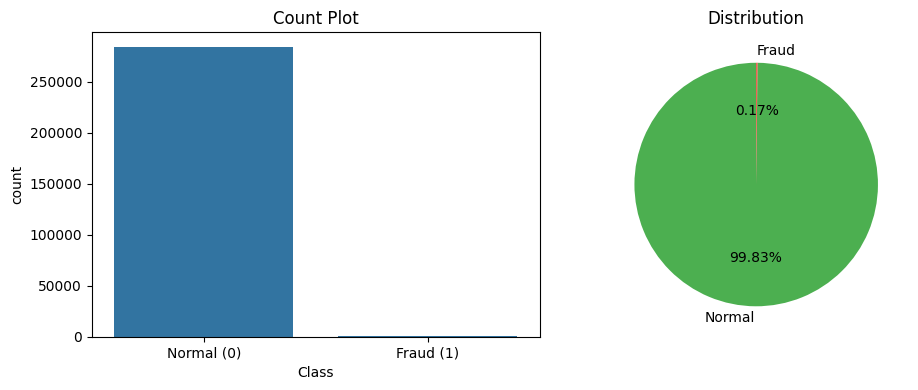

In [3]:
class_counts = df['Class'].value_counts()
print('Distribusi Class:')
print(class_counts)
print(f'\nPersentase fraud: {class_counts[1]/len(df)*100:.4f}%')

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(data=df, x='Class', ax=ax[0])
ax[0].set_title('Count Plot')
ax[0].set_xticklabels(['Normal (0)', 'Fraud (1)'])

colors = ['#4CAF50', '#F44336']
ax[1].pie(class_counts.values, labels=['Normal', 'Fraud'],
          autopct='%1.2f%%', colors=colors, startangle=90)
ax[1].set_title('Distribution')
plt.tight_layout()
plt.show()

**Temuan:** Dataset sangat tidak seimbang — fraud hanya 0.17%. Ini akan menjadi tantangan utama dalam preprocessing dan modeling nantinya.

## 4.2 Distribusi Time dan Amount

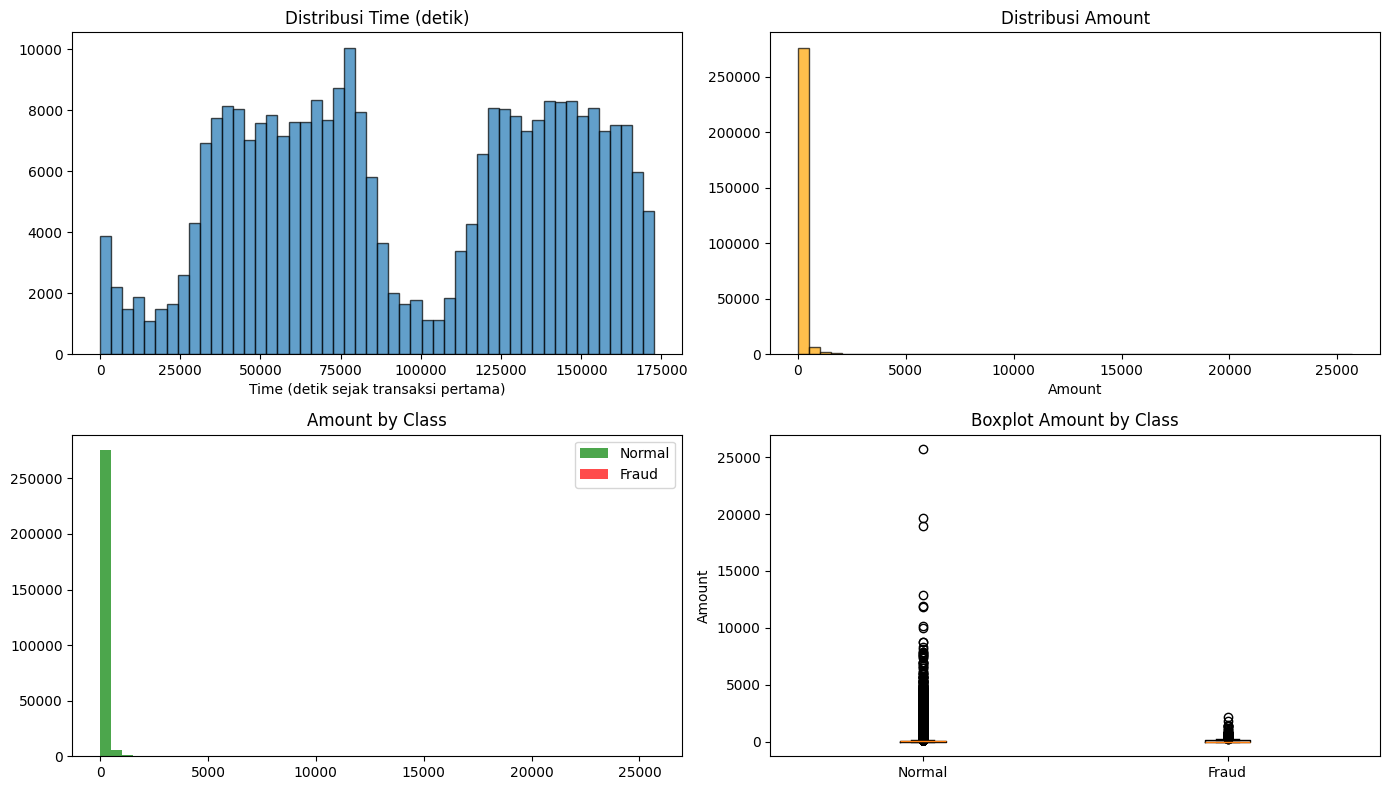

Statistik Amount per Class:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].hist(df['Time'], bins=50, edgecolor='black', alpha=0.7)
axes[0,0].set_title('Distribusi Time (detik)')
axes[0,0].set_xlabel('Time (detik sejak transaksi pertama)')

axes[0,1].hist(df['Amount'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0,1].set_title('Distribusi Amount')
axes[0,1].set_xlabel('Amount')

axes[1,0].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.7, label='Normal', color='green')
axes[1,0].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.7, label='Fraud', color='red')
axes[1,0].set_title('Amount by Class')
axes[1,0].legend()

axes[1,1].boxplot([df[df['Class']==0]['Amount'], df[df['Class']==1]['Amount']],
                  labels=['Normal', 'Fraud'])
axes[1,1].set_title('Boxplot Amount by Class')
axes[1,1].set_ylabel('Amount')

plt.tight_layout()
plt.show()

print('Statistik Amount per Class:')
print(df.groupby('Class')['Amount'].describe())

**Temuan:**
- `Time` terdistribusi cukup merata sepanjang 2 hari (172.792 detik ≈ 48 jam).
- `Amount` sangat right-skewed — mayoritas transaksi kecil (median $22), dengan beberapa outlier besar hingga $25.691.
- Transaksi fraud cenderung memiliki amount yang lebih kecil dibanding normal.

## 4.3 Missing Values dan Duplikasi

In [5]:
print('Missing values per kolom:')
print(df.isnull().sum().to_string())
print(f'\nTotal missing: {df.isnull().sum().sum()}')
print(f'\nJumlah duplikat: {df.duplicated().sum()}')

Missing values per kolom:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0

Total missing: 0

Jumlah duplikat: 1081


**Temuan:** Tidak ada missing values. Ada 1.081 baris duplikat yang perlu di-handle nanti.

## 4.4 Korelasi Fitur PCA terhadap Class

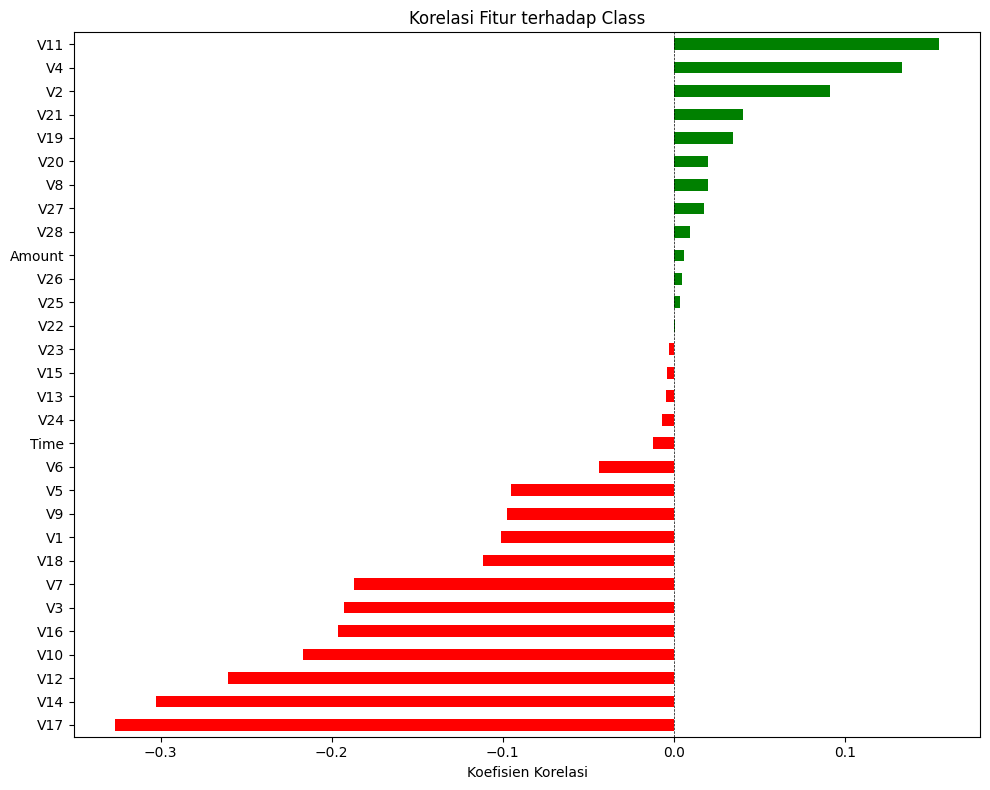

Korelasi tertinggi (positif):
V11    0.154876
V4     0.133447
V2     0.091289
V21    0.040413
V19    0.034783
Name: Class, dtype: float64

Korelasi terendah (negatif):
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64


In [6]:
corr_with_class = df.corr()['Class'].drop('Class').sort_values()

plt.figure(figsize=(10, 8))
colors = ['red' if v < 0 else 'green' for v in corr_with_class.values]
corr_with_class.plot(kind='barh', color=colors)
plt.title('Korelasi Fitur terhadap Class')
plt.xlabel('Koefisien Korelasi')
plt.axvline(0, color='black', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

print('Korelasi tertinggi (positif):')
print(corr_with_class.sort_values(ascending=False).head(5))
print('\nKorelasi terendah (negatif):')
print(corr_with_class.sort_values(ascending=True).head(5))

**Temuan:**
- V11, V4, V2, V21 memiliki korelasi positif tertinggi dengan fraud.
- V17, V14, V12, V10 memiliki korelasi negatif tertinggi.
- `Time` dan `Amount` hampir tidak berkorelasi dengan `Class`.
- **Korelasi sangat rendah** karena sifat data yang sangat imbalanced — ini wajar dan bukan masalah.

## 4.5 Deteksi Outlier pada Amount

In [7]:
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Amount'] < lower) | (df['Amount'] > upper)]
print(f'Batas outlier (IQR): lower={lower:.2f}, upper={upper:.2f}')
print(f'Jumlah outlier Amount: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)')
print(f'\nStatistik outlier:')
print(outliers['Amount'].describe())

Batas outlier (IQR): lower=-101.75, upper=184.51
Jumlah outlier Amount: 31904 (11.20%)

Statistik outlier:
count    31904.000000
mean       511.451107
std        585.479806
min        184.520000
25%        239.642500
50%        334.000000
75%        550.785000
max      25691.160000
Name: Amount, dtype: float64


**Temuan:** Terdapat banyak outlier pada `Amount`. Namun, karena fraud sering terjadi pada transaksi dengan nilai yang tidak biasa, penghapusan outlier BUKAN langkah yang bijak. Kita akan menggunakan **RobustScaler** untuk `Amount` agar outlier tidak mendominasi scaling.

## 4.6 Statistik Deskriptif V1-V28

In [8]:
v_cols = [f'V{i}' for i in range(1, 29)]
print('Statistik deskriptif V1-V28:')
display(df[v_cols].describe().round(4))

Statistik deskriptif V1-V28:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
count,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,...,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000
mean,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,...,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000
std,1.9587,1.6513,1.5163,1.4159,1.3802,1.3323,1.2371,1.1944,1.0986,1.0888,...,0.8140,0.7709,0.7345,0.7257,0.6245,0.6056,0.5213,0.4822,0.4036,0.3301
min,-56.4075,-72.7157,-48.3256,-5.6832,-113.7433,-26.1605,-43.5572,-73.2167,-13.4341,-24.5883,...,-7.2135,-54.4977,-34.8304,-10.9331,-44.8077,-2.8366,-10.2954,-2.6046,-22.5657,-15.4301
25%,-0.9204,-0.5985,-0.8904,-0.8486,-0.6916,-0.7683,-0.5541,-0.2086,-0.6431,-0.5354,...,-0.4563,-0.2117,-0.2284,-0.5424,-0.1618,-0.3546,-0.3171,-0.3270,-0.0708,-0.0530
50%,0.0181,0.0655,0.1798,-0.0198,-0.0543,-0.2742,0.0401,0.0224,-0.0514,-0.0929,...,0.0037,-0.0625,-0.0295,0.0068,-0.0112,0.0410,0.0166,-0.0521,0.0013,0.0112
75%,1.3156,0.8037,1.0272,0.7433,0.6119,0.3986,0.5704,0.3273,0.5971,0.4539,...,0.4589,0.1330,0.1864,0.5286,0.1476,0.4395,0.3507,0.2410,0.0910,0.0783
max,2.4549,22.0577,9.3826,16.8753,34.8017,73.3016,120.5895,20.0072,15.5950,23.7451,...,5.5920,39.4209,27.2028,10.5031,22.5284,4.5845,7.5196,3.5173,31.6122,33.8478


**Temuan:** Semua fitur V1-V28 memiliki mean ≈ 0 dan std ≈ 1. Ini menandakan data sudah ternormalisasi (hasil PCA). Tidak perlu scaling ulang untuk fitur-fitur ini.

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

**Langkah yang dilakukan:**
1. Menangani duplikasi.
2. Scaling `Time` (StandardScaler) dan `Amount` (RobustScaler karena outlier).
3. Memisahkan fitur dan target.
4. Stratified train-test split (menjaga proporsi fraud).
5. SMOTE oversampling pada data training.
6. Menyimpan hasil preprocessing.


## 5.1 Menangani Duplikasi

In [9]:
print(f'Duplikat sebelum: {df.duplicated().sum()}')
df_clean = df.drop_duplicates()
print(f'Duplikat setelah: {df_clean.duplicated().sum()}')
print(f'Shape setelah drop duplicates: {df_clean.shape}')

Duplikat sebelum: 1081
Duplikat setelah: 0
Shape setelah drop duplicates: (283726, 31)


**Reasoning:** Duplikat pada data transaksi kartu kredit bisa terjadi karena entry ganda atau pengambilan data yang redundant. Kita hapus untuk menghindari data leakage.

## 5.2 Scaling Time dan Amount

In [10]:
from sklearn.preprocessing import RobustScaler

X = df_clean.copy()

scaler_time = StandardScaler()
X['Time'] = scaler_time.fit_transform(X[['Time']])

scaler_amount = RobustScaler()
X['Amount'] = scaler_amount.fit_transform(X[['Amount']])

print('Time setelah StandardScaler:')
print(f'  Mean: {X["Time"].mean():.4f}, Std: {X["Time"].std():.4f}')
print('Amount setelah RobustScaler:')
print(f'  Median: {X["Amount"].median():.4f}, IQR-range approx: {X["Amount"].quantile(0.75)-X["Amount"].quantile(0.25):.4f}')

Time setelah StandardScaler:
  Mean: 0.0000, Std: 1.0000
Amount setelah RobustScaler:
  Median: 0.0000, IQR-range approx: 1.0000


**Reasoning:**
- `Time` tidak memiliki outlier ekstrem, cukup pakai StandardScaler.
- `Amount` sangat right-skewed dengan banyak outlier. RobustScaler (berbasis median dan IQR) lebih cocok daripada StandardScaler karena tidak terpengaruh outlier.
- V1-V28 sudah ternormalisasi dari PCA (mean≈0, std≈1), tidak perlu di-scale ulang.

## 5.3 Memisahkan Fitur dan Target

In [11]:
y = X['Class']
X_features = X.drop('Class', axis=1)

print('X shape:', X_features.shape)
print('y shape:', y.shape)
print(f'Proporsi fraud di y: {y.mean()*100:.4f}%')

X shape: (283726, 30)
y shape: (283726,)
Proporsi fraud di y: 0.1667%


## 5.4 Stratified Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train size: {len(X_train)}, Test size: {len(X_test)}')
print(f'\nDistribusi train:\n{y_train.value_counts().to_string()}')
print(f'Fraud % di train: {y_train.mean()*100:.4f}%')
print(f'\nDistribusi test:\n{y_test.value_counts().to_string()}')
print(f'Fraud % di test: {y_test.mean()*100:.4f}%')

Train size: 226980, Test size: 56746

Distribusi train:
Class
0    226602
1       378
Fraud % di train: 0.1665%

Distribusi test:
Class
0    56651
1       95
Fraud % di test: 0.1674%


**Reasoning:** Stratify wajib digunakan karena data sangat imbalanced (fraud hanya 0.17%). Tanpa stratify, ada risiko test set tidak mengandung fraud sama sekali, yang akan membuat evaluasi model tidak bermakna.

## 5.5 SMOTE Oversampling (Training Set Only)

In [13]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('Setelah SMOTE:')
train_res_counts = y_train_res.value_counts()
print(train_res_counts)
print(f'Rasio: {train_res_counts[0] / train_res_counts[1]:.2f}:1')

Setelah SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64
Rasio: 1.00:1


**Reasoning:** SMOTE membuat synthetic samples untuk kelas minoritas (fraud) di training set, sehingga model tidak bias ke kelas mayoritas. SMOTE hanya diterapkan pada training set untuk menghindari data leakage ke test set.

## 5.6 Menyimpan Hasil Preprocessing

In [14]:
import os

output_dir = 'creditcard_preprocessing'
os.makedirs(output_dir, exist_ok=True)

pd.DataFrame(X_train, columns=X_features.columns).to_csv(
    f'{output_dir}/X_train.csv', index=False)
pd.DataFrame(X_test, columns=X_features.columns).to_csv(
    f'{output_dir}/X_test.csv', index=False)
pd.DataFrame(X_train_res, columns=X_features.columns).to_csv(
    f'{output_dir}/X_train_resampled.csv', index=False)
pd.DataFrame(y_train, columns=['Class']).to_csv(
    f'{output_dir}/y_train.csv', index=False)
pd.DataFrame(y_test, columns=['Class']).to_csv(
    f'{output_dir}/y_test.csv', index=False)
pd.DataFrame(y_train_res, columns=['Class']).to_csv(
    f'{output_dir}/y_train_resampled.csv', index=False)

print('Semua file preprocessing tersimpan di folder:', output_dir)
print(f'\nDaftar file:')
for f in sorted(os.listdir(output_dir)):
    fpath = os.path.join(output_dir, f)
    fsize = os.path.getsize(fpath)
    print(f'  {f}: {fsize/1024:.1f} KB')

Semua file preprocessing tersimpan di folder: creditcard_preprocessing

Daftar file:
  X_test.csv: 30646.2 KB
  X_train.csv: 122576.6 KB
  X_train_resampled.csv: 251573.7 KB
  y_test.csv: 110.8 KB
  y_train.csv: 443.3 KB
  y_train_resampled.csv: 885.2 KB


## 5.7 Ringkasan Preprocessing

**Kesimpulan Preprocessing:**
- **Duplikasi**: 1.081 baris duplikat dihapus.
- **Missing Values**: Tidak ada.
- **Scaling**: `Time` → StandardScaler, `Amount` → RobustScaler (karena outlier). V1-V28 tidak di-scale (sudah normal dari PCA).
- **Train/Test Split**: 80/20, stratified by Class.
- **SMOTE**: Synthetic oversampling pada training set untuk menyeimbangkan kelas.
- **Output**: 6 file CSV siap pakai untuk modeling.

Dataset preprocessing ini siap digunakan di repositori **Membangun_Model** (Kriteria 2) dan **Workflow-CI** (Kriteria 3).